# Task 1 – Data Profiling & Data Quality

**Goal:** Before modelling anything, get an overview of the data quality of `leads.csv` and `conversions.csv`:
row counts, missing values, duplicates, suspicious values and value ranges — and derive a list of concrete
data-quality (DQ) issues with criticality and handling.

**Approach**
1. Load both files **as raw strings** (`dtype=str`) so that pandas does not silently coerce / hide problems
   (e.g. `"1299,57"` becoming NaN, leading whitespace being kept but invisible, dates being guessed).
2. Profile each column on the raw layer.
3. Try the *intended* typing (numbers, dates, categories) and measure what fails.
4. Check cross-file consistency (referential integrity, email agreement, date plausibility).
5. Summarise everything in a DQ issue register (end of notebook).

> Cleaning itself is *not* done here — this notebook only measures. The handling decisions feed into Task 2 (staging layer).

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data" / "raw"

# Read everything as string, do not convert "" to NaN automatically -> we want to see the raw truth.
leads_raw = pd.read_csv(DATA_DIR / "leads.csv", dtype=str, keep_default_na=False)
conv_raw = pd.read_csv(DATA_DIR / "conversions.csv", dtype=str, keep_default_na=False)

print("pandas", pd.__version__)

pandas 3.0.6


## 1. First look & row counts

In [2]:
for name, df in {"leads": leads_raw, "conversions": conv_raw}.items():
    print(f"{name:12s} rows={len(df):4d}  cols={df.shape[1]}  columns={list(df.columns)}")

leads        rows= 123  cols=6  columns=['lead_id', 'email', 'vertical', 'source', 'created_at', 'region']
conversions  rows=  51  cols=6  columns=['conversion_id', 'lead_id', 'email', 'premium', 'signed_date', 'status']


In [3]:
leads_raw.head(10)

,lead_id,email,vertical,source,created_at,region
0,1087,Sophia.wagner@aon.at,haushalt,direct,05/02/2024,
1,1056,lea.brunner@outlook.com,haushalt,newsletter,2024-04-22,Kaernten
2,1071,michael.fischer@gmx.at,auto,google,25.09.2024,Vorarlberg
3,1095,emma.leitner@outlook.com,haushalt,google,2024-10-30,Kaernten
4,1032,clara.moser@gmail.com,leben,direct,06.10.2024,Salzburg
5,1009,Anna.aigner@gmx.at,leben,google,22.10.2024,Kaernten
6,1097,lea.weber@outlook.com,leben,google,2024-07-28,Salzburg
7,1028,sophie.aigner@hotmail.com,leben,newsletter,26.05.2024,Burgenland
8,1084,lukas.mayer@aon.at,leben,google,11.08.2024,Niederoesterreich
9,1098,felix.mayer@gmx.at,haushalt,direct,03/04/2024,Wien


In [4]:
conv_raw.head(10)

,conversion_id,lead_id,email,premium,signed_date,status
0,5036,1103,sophie.gruber@gmx.at,422.42,15.03.2024,active
1,5021,1047,julia.brunner@hotmail.com,"1299,57",04.03.2024,active
2,5001,1076,julia.pichler@hotmail.com,"431,77",30.04.2024,active
3,5030,1111,ELIAS.WINKLER@OUTLOOK.COM,"212,26",08/12/2024,cancelled
4,5041,1007,anna.wagner@gmx.at,218.22,02.07.2024,cancelled
5,5037,1117,noah.gruber@gmail.com,346.75,24.08.2024,cancelled
6,5017,1028,sophie.aigner@hotmail.com,1359.55,2024-05-30,active
7,5048,,julia.mueller@gmail.com,1293.44,17.03.2024,pending
8,5028,1008,tobias.weber@aon.at,"1102,21",2024-10-05,cancelled
9,5047,99874,paul.aigner@hotmail.com,442.55,2024-05-29,pending


## 2. Generic column profile

A small helper that reports, per column: empty/blank values, distinct values, values with leading/trailing
whitespace, values that change when lower-cased, and min/max length.

In [5]:
def profile(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        s = df[col]
        blank = s.str.strip().eq("")
        rows.append({
            "column": col,
            "rows": len(s),
            "blank_or_empty": int(blank.sum()),
            "blank_pct": round(100 * blank.mean(), 1),
            "distinct_raw": s.nunique(),
            "distinct_trim_lower": s.str.strip().str.lower().nunique(),
            "has_outer_whitespace": int((s != s.str.strip()).sum()),
            "has_uppercase": int((s != s.str.lower()).sum()),
            "min_len": s.str.len().min(),
            "max_len": s.str.len().max(),
        })
    return pd.DataFrame(rows).set_index("column")

profile(leads_raw)

,rows,blank_or_empty,blank_pct,distinct_raw,distinct_trim_lower,has_outer_whitespace,has_uppercase,min_len,max_len
column,,,,,,,,,
lead_id,123,0,0.0,119,119,0,0,4,4
email,123,0,0.0,103,88,17,20,16,28
vertical,123,3,2.4,4,4,0,0,0,8
source,123,0,0.0,3,3,0,0,6,10
created_at,123,0,0.0,109,109,0,0,10,10
region,123,5,4.1,10,10,0,118,0,17


In [6]:
profile(conv_raw)

,rows,blank_or_empty,blank_pct,distinct_raw,distinct_trim_lower,has_outer_whitespace,has_uppercase,min_len,max_len
column,,,,,,,,,
conversion_id,51,0,0.0,50,50,0,0,4,4
lead_id,51,3,5.9,48,48,0,0,0,5
email,51,0,0.0,43,41,6,7,17,27
premium,51,2,3.9,49,49,0,0,0,7
signed_date,51,0,0.0,47,47,0,0,10,10
status,51,0,0.0,5,4,0,1,5,9


**Reading the profile:** `distinct_raw` vs `distinct_trim_lower` shows how many "different" values are only
different because of casing/whitespace. The categorical columns are inspected in detail below.

## 3. Missing values

In [7]:
def missing_report(df):
    blank = df.apply(lambda s: s.str.strip().eq(""))
    return pd.DataFrame({"missing": blank.sum(), "missing_pct": (100 * blank.mean()).round(1)})

print("LEADS"); display(missing_report(leads_raw))
print("CONVERSIONS"); display(missing_report(conv_raw))

LEADS


,missing,missing_pct
lead_id,0,0.0
email,0,0.0
vertical,3,2.4
source,0,0.0
created_at,0,0.0
region,5,4.1


CONVERSIONS


,missing,missing_pct
conversion_id,0,0.0
lead_id,3,5.9
email,0,0.0
premium,2,3.9
signed_date,0,0.0
status,0,0.0


In [8]:
# Which rows exactly?
display(leads_raw[leads_raw.apply(lambda s: s.str.strip().eq("")).any(axis=1)])
display(conv_raw[conv_raw.apply(lambda s: s.str.strip().eq("")).any(axis=1)])

,lead_id,email,vertical,source,created_at,region
0,1087,Sophia.wagner@aon.at,haushalt,direct,05/02/2024,
18,1075,SOPHIA.WEBER@AON.AT,,newsletter,2024-05-12,Tirol
20,1021,florian.fuchs@aon.at,haushalt,google,03/10/2024,
40,1045,tobias.gruber@hotmail.com,,direct,10/11/2024,Vorarlberg
48,1010,emma.aigner@outlook.com,haushalt,google,20.10.2024,
62,1070,mia.berger@gmail.com,haushalt,newsletter,2024-04-07,
65,1076,JULIA.PICHLER@HOTMAIL.COM,,newsletter,2024-04-08,Burgenland
77,1057,florian.mayer@gmx.at,leben,direct,2024-02-15,


,conversion_id,lead_id,email,premium,signed_date,status
7,5048,,julia.mueller@gmail.com,1293.44,17.03.2024,pending
20,5050,,clara.winkler@gmx.at,1160.88,06/21/2024,pending
23,5024,1104,sophie.gruber@hotmail.com,,01.07.2024,active
35,5049,,mia.berger@gmail.com,881.65,2024-03-11,cancelled
39,5033,1059,mia.gruber@gmail.com,,08.02.2024,cancelled


## 4. Duplicates

Three levels of duplicates are checked:
1. **Exact duplicate rows** (identical in every column).
2. **Duplicate primary keys** (`lead_id` / `conversion_id`) — and whether the duplicates *conflict* in other columns.
3. **Duplicate entities** — the same person (normalised email) appearing with several lead ids.
   This is not necessarily an error (a person can use the calculator several times), but it is important
   for the "what is a customer" definition in Task 3.

In [9]:
for name, df, key in [("leads", leads_raw, "lead_id"), ("conversions", conv_raw, "conversion_id")]:
    exact = df.duplicated(keep=False)
    key_dup = df.duplicated(subset=[key], keep=False)
    print(f"{name}: exact duplicate rows = {df.duplicated().sum()} "
          f"(rows involved: {exact.sum()}), duplicate {key} values = {df[key][key_dup].nunique()}")

leads: exact duplicate rows = 0 (rows involved: 0), duplicate lead_id values = 4
conversions: exact duplicate rows = 1 (rows involved: 2), duplicate conversion_id values = 1


In [10]:
# Duplicate lead_ids: which columns differ between the copies?
dup_leads = leads_raw[leads_raw.duplicated("lead_id", keep=False)].sort_values("lead_id")
display(dup_leads)

def differing_columns(g):
    g = g.apply(lambda s: s.str.strip().str.lower())
    return [c for c in g.columns if g[c].nunique() > 1]

conflicts = dup_leads.groupby("lead_id").apply(differing_columns, include_groups=False)
conflicts.rename("columns_that_differ").to_frame()

,lead_id,email,vertical,source,created_at,region
55,1019,sophie.eder@gmail.com,haushalt,direct,2024-08-18,Niederoesterreich
86,1019,sophie.eder@gmail.com,haushalt,direct,2024-08-18,Wien
90,1030,sophie.aigner@hotmail.com,haushalt,newsletter,24.01.2024,Salzburg
115,1030,sophie.aigner@hotmail.com,haushalt,newsletter,24.01.2024,Tirol
18,1075,SOPHIA.WEBER@AON.AT,,newsletter,2024-05-12,Tirol
75,1075,SOPHIA.WEBER@AON.AT,leben,google,2024-05-12,Burgenland
10,1117,NOAH.GRUBER@GMAIL.COM,haushalt,newsletter,2024-08-19,Tirol
17,1117,NOAH.GRUBER@GMAIL.COM,haushalt,google,2024-08-19,Wien


,columns_that_differ
lead_id,
1019,[region]
1030,[region]
1075,"[vertical, source, region]"
1117,"[source, region]"


In [11]:
dup_conv = conv_raw[conv_raw.duplicated("conversion_id", keep=False)].sort_values("conversion_id")
dup_conv

,conversion_id,lead_id,email,premium,signed_date,status
19,5020,1031,sophia.lang@hotmail.com,153.60,2024-10-28,pending
26,5020,1031,sophia.lang@hotmail.com,153.60,2024-10-28,pending


In [12]:
# Same person, several lead_ids (after normalising email = trim + lower-case)
leads_raw["email_norm"] = leads_raw["email"].str.strip().str.lower()
per_email = (leads_raw.drop_duplicates()
             .groupby("email_norm")["lead_id"].agg(["nunique", lambda s: sorted(s.unique())])
             .rename(columns={"nunique": "n_lead_ids", "<lambda_0>": "lead_ids"}))
multi = per_email[per_email["n_lead_ids"] > 1].sort_values("n_lead_ids", ascending=False)
print(f"distinct raw emails: {leads_raw['email'].nunique()}  | distinct normalised emails: {leads_raw['email_norm'].nunique()}")
print(f"normalised emails with >1 lead_id: {len(multi)}")
multi

distinct raw emails: 103  | distinct normalised emails: 88
normalised emails with >1 lead_id: 21


,n_lead_ids,lead_ids
email_norm,,
mia.berger@gmail.com,4,"[1016, 1017, 1069, 1070]"
florian.fuchs@aon.at,3,"[1020, 1021, 1022]"
laura.pichler@gmx.at,3,"[1014, 1015, 1050]"
julia.pichler@hotmail.com,3,"[1076, 1077, 1078]"
emma.leitner@outlook.com,3,"[1093, 1094, 1095]"
noah.gruber@gmail.com,3,"[1115, 1116, 1117]"
sophie.aigner@hotmail.com,3,"[1028, 1029, 1030]"
laura.gruber@outlook.com,3,"[1023, 1024, 1025]"
leon.aigner@aon.at,3,"[1051, 1052, 1053]"


In [13]:
# Same local part (name) but different email domain -> possibly same person, cannot be proven from the data
local = leads_raw.assign(local=leads_raw["email_norm"].str.split("@").str[0],
                         domain=leads_raw["email_norm"].str.split("@").str[1])
same_name = local.groupby("local")["domain"].nunique()
local[local["local"].isin(same_name[same_name > 1].index)][["lead_id", "email_norm", "vertical", "created_at"]].sort_values("email_norm")

,lead_id,email_norm,vertical,created_at
20,1021,florian.fuchs@aon.at,haushalt,03/10/2024
25,1020,florian.fuchs@aon.at,haushalt,21.03.2024
53,1022,florian.fuchs@aon.at,haushalt,05/11/2024
91,1037,florian.fuchs@gmx.at,leben,18.08.2024
106,1046,lena.hofer@gmail.com,haushalt,2024-05-10
63,1035,lena.hofer@outlook.com,auto,17.07.2024
8,1084,lukas.mayer@aon.at,leben,11.08.2024
100,1085,lukas.mayer@aon.at,haushalt,2024-04-20
118,1033,lukas.mayer@hotmail.com,leben,22.06.2024
76,1005,paul.aigner@gmail.com,leben,08/24/2024


## 5. Categorical columns – value sets vs. specification

In [14]:
EXPECTED = {
    ("leads", "vertical"): {"auto", "haushalt", "leben"},
    ("leads", "source"): {"google", "newsletter", "direct"},
    ("conversions", "status"): {"active", "cancelled", "pending"},
}
frames = {"leads": leads_raw, "conversions": conv_raw}

for (tbl, col), allowed in EXPECTED.items():
    vc = frames[tbl][col].value_counts(dropna=False)
    bad = [v for v in vc.index if v not in allowed]
    print(f"--- {tbl}.{col}  (spec: {sorted(allowed)})")
    print(vc.to_string())
    print(f"  -> values outside spec: {bad}\n")

--- leads.vertical  (spec: ['auto', 'haushalt', 'leben'])
vertical
haushalt    44
leben       44
auto        32
             3
  -> values outside spec: ['']

--- leads.source  (spec: ['direct', 'google', 'newsletter'])
source
newsletter    44
direct        41
google        38
  -> values outside spec: []

--- conversions.status  (spec: ['active', 'cancelled', 'pending'])
status
active       25
cancelled    16
pending       8
aktiv         1
ACTIVE        1
  -> values outside spec: ['aktiv', 'ACTIVE']



In [15]:
# Region has no spec -> check the value set (Austrian federal states, ASCII-transliterated)
AT_STATES = {"Wien", "Niederoesterreich", "Oberoesterreich", "Steiermark", "Tirol",
             "Kaernten", "Salzburg", "Vorarlberg", "Burgenland"}
vc = leads_raw["region"].value_counts()
print(vc.to_string())
print("\nnot a known federal state:", [v for v in vc.index if v not in AT_STATES])

region
Kaernten             17
Vorarlberg           17
Tirol                16
Niederoesterreich    15
Oberoesterreich      14
Burgenland           13
Wien                 11
Steiermark            8
Salzburg              7
                      5

not a known federal state: ['']


## 6. IDs

Check that ids are integers, and look at their ranges. Lead ids in `conversions` that are outside the lead-id
range are a strong hint for broken references.

In [16]:
def id_profile(s: pd.Series) -> pd.Series:
    num = pd.to_numeric(s.str.strip().replace("", np.nan), errors="coerce")
    return pd.Series({"non_blank": s.str.strip().ne("").sum(), "non_integer": int((s.str.strip().ne("") & num.isna()).sum()),
                      "min": num.min(), "max": num.max(), "distinct": num.nunique()})

pd.DataFrame({
    "leads.lead_id": id_profile(leads_raw["lead_id"]),
    "conversions.conversion_id": id_profile(conv_raw["conversion_id"]),
    "conversions.lead_id": id_profile(conv_raw["lead_id"]),
})

,leads.lead_id,conversions.conversion_id,conversions.lead_id
non_blank,123,51,48.0
non_integer,0,0,0.0
min,1001,5001,1003.0
max,1119,5050,99874.0
distinct,119,50,47.0


In [17]:
# Gaps in the id sequences (not necessarily an error, but good to know: were records dropped in an export?)
lead_ids = set(pd.to_numeric(leads_raw["lead_id"]))
conv_ids = set(pd.to_numeric(conv_raw["conversion_id"]))
print("missing lead_ids in range      :", sorted(set(range(min(lead_ids), max(lead_ids) + 1)) - lead_ids))
print("missing conversion_ids in range:", sorted(set(range(min(conv_ids), max(conv_ids) + 1)) - conv_ids))

missing lead_ids in range      : []
missing conversion_ids in range: []


## 7. Dates – format detection and parsing

`created_at` and `signed_date` are stored as strings in mixed formats. First classify each value by pattern,
then decide how to parse the ambiguous `xx/xx/yyyy` format.

In [18]:
PATTERNS = {
    "ISO yyyy-mm-dd": r"^\d{4}-\d{2}-\d{2}$",
    "DE dd.mm.yyyy": r"^\d{2}\.\d{2}\.\d{4}$",
    "slash xx/xx/yyyy": r"^\d{2}/\d{2}/\d{4}$",
}

def date_format(v: str) -> str:
    v = v.strip()
    if v == "":
        return "blank"
    for name, pat in PATTERNS.items():
        if re.match(pat, v):
            return name
    return "OTHER"

fmt = pd.concat([
    leads_raw["created_at"].map(date_format).value_counts().rename("leads.created_at"),
    conv_raw["signed_date"].map(date_format).value_counts().rename("conversions.signed_date"),
], axis=1).fillna(0).astype(int)
fmt

,leads.created_at,conversions.signed_date
ISO yyyy-mm-dd,61,27
DE dd.mm.yyyy,36,16
slash xx/xx/yyyy,26,8


In [19]:
# Is the slash format MM/DD (US) or DD/MM (EU)? Look at values where one side is > 12 -> unambiguous.
slash = pd.concat([leads_raw["created_at"], conv_raw["signed_date"]]).str.strip()
slash = slash[slash.map(date_format) == "slash xx/xx/yyyy"]
parts = slash.str.extract(r"^(?P<a>\d{2})/(?P<b>\d{2})/(?P<y>\d{4})$").astype(int)

print("slash dates total             :", len(parts))
print("first part > 12  (=> DD/MM)   :", int((parts.a > 12).sum()))
print("second part > 12 (=> MM/DD)   :", int((parts.b > 12).sum()))
print("both <= 12 (truly ambiguous)  :", int(((parts.a <= 12) & (parts.b <= 12)).sum()))

slash dates total             : 34
first part > 12  (=> DD/MM)   : 0
second part > 12 (=> MM/DD)   : 18
both <= 12 (truly ambiguous)  : 16


**Finding:** every *unambiguous* slash date is `MM/DD/YYYY` (US), none is `DD/MM`. Assumption: all slash dates
come from the same (US-formatted) source system → parse as `%m/%d/%Y`. The ambiguous ones are flagged as an
assumption; they are validated below via the plausibility check *signed_date ≥ created_at*.

In [20]:
FORMATS = {"ISO yyyy-mm-dd": "%Y-%m-%d", "DE dd.mm.yyyy": "%d.%m.%Y", "slash xx/xx/yyyy": "%m/%d/%Y"}

def parse_date(v: str):
    f = date_format(v)
    return pd.to_datetime(v.strip(), format=FORMATS[f]) if f in FORMATS else pd.NaT

leads_raw["created_at_parsed"] = leads_raw["created_at"].map(parse_date)
conv_raw["signed_date_parsed"] = conv_raw["signed_date"].map(parse_date)

for label, s in [("created_at", leads_raw["created_at_parsed"]), ("signed_date", conv_raw["signed_date_parsed"])]:
    print(f"{label:12s} parsed={s.notna().sum()}  failed={s.isna().sum()}  min={s.min().date()}  max={s.max().date()}")

created_at   parsed=123  failed=0  min=2024-01-05  max=2024-10-31
signed_date  parsed=51  failed=0  min=2024-01-16  max=2024-11-29


In [21]:
# Distribution per month (sanity check: no strange spikes / out-of-range months)
pd.concat([
    leads_raw["created_at_parsed"].dt.to_period("M").value_counts().rename("leads"),
    conv_raw["signed_date_parsed"].dt.to_period("M").value_counts().rename("conversions"),
], axis=1).sort_index().fillna(0).astype(int)

,leads,conversions
2024-01,7,1
2024-02,11,3
2024-03,10,8
2024-04,15,5
2024-05,17,4
2024-06,14,8
2024-07,10,6
2024-08,13,2
2024-09,6,4
2024-10,20,5


## 8. Premium – numeric parsing and value range

In [22]:
p = conv_raw["premium"].str.strip()
premium_fmt = np.select(
    [p.eq(""), p.str.match(r"^-?\d+\.\d+$"), p.str.match(r"^-?\d+,\d+$"), p.str.match(r"^-?\d+$")],
    ["blank", "decimal point", "decimal comma", "integer"], default="OTHER")
print(pd.Series(premium_fmt).value_counts().to_string())

# Decimal comma -> decimal point (no thousand separators present, checked by the regex above)
conv_raw["premium_parsed"] = pd.to_numeric(p.str.replace(",", ".", regex=False).replace("", np.nan), errors="coerce")
conv_raw["premium_parsed"].describe()

decimal point    36
decimal comma    13
blank             2

count      49.000000
mean      597.104898
std       399.500814
min      -217.610000
25%       260.710000
50%       570.490000
75%       881.650000
max      1359.550000
Name: premium_parsed, dtype: float64

In [23]:
# Suspicious premiums: negative, zero, missing, statistical outliers (IQR rule)
pp = conv_raw["premium_parsed"]
q1, q3 = pp.quantile([0.25, 0.75])
iqr = q3 - q1
conv_raw["premium_flag"] = np.select(
    [pp.isna(), pp < 0, pp == 0, (pp < q1 - 1.5 * iqr) | (pp > q3 + 1.5 * iqr)],
    ["missing", "negative", "zero", "outlier (IQR)"], default="")
print(f"IQR bounds: [{q1 - 1.5 * iqr:.2f}, {q3 + 1.5 * iqr:.2f}]")
conv_raw.loc[conv_raw["premium_flag"] != "", ["conversion_id", "lead_id", "premium", "premium_parsed", "status", "premium_flag"]]

IQR bounds: [-670.70, 1813.06]


,conversion_id,lead_id,premium,premium_parsed,status,premium_flag
23,5024,1104,,NaN,active,missing
32,5044,92827,-73.36,-73.36,cancelled,negative
37,5034,1012,-217.61,-217.61,cancelled,negative
39,5033,1059,,NaN,cancelled,missing


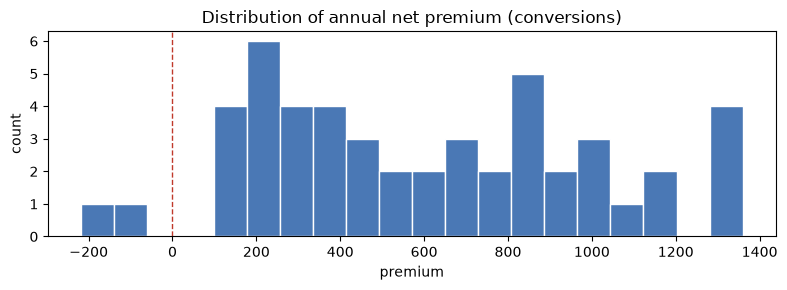

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(pp.dropna(), bins=20, color="#4a78b5", edgecolor="white")
ax.axvline(0, color="#c0392b", linestyle="--", linewidth=1)
ax.set_title("Distribution of annual net premium (conversions)")
ax.set_xlabel("premium"); ax.set_ylabel("count")
plt.tight_layout(); plt.show()

## 9. Cross-file checks (conversions → leads)

1. **Referential integrity:** does every `conversions.lead_id` exist in `leads`?
2. **Email agreement:** does the conversion email match the email of the referenced lead (after normalisation)?
3. **Can orphans be rescued via email?**
4. **Temporal plausibility:** `signed_date` must not be before `created_at`.
5. **Cardinality:** how many conversions per lead?

In [25]:
conv_raw["email_norm"] = conv_raw["email"].str.strip().str.lower()
leads_dedup = leads_raw.drop_duplicates("lead_id")   # only for lookup purposes here
lead_ids_str = set(leads_dedup["lead_id"])

def ref_status(v):
    v = v.strip()
    if v == "":
        return "lead_id missing"
    return "matched" if v in lead_ids_str else "lead_id not in leads"

conv_raw["ref_status"] = conv_raw["lead_id"].map(ref_status)
conv_raw["ref_status"].value_counts()

ref_status
matched                 42
lead_id not in leads     6
lead_id missing          3
Name: count, dtype: int64

In [26]:
# Orphans: can we find the person via email?
emails_in_leads = leads_dedup.groupby("email_norm")["lead_id"].apply(list)
orphans = conv_raw[conv_raw["ref_status"] != "matched"].copy()
orphans["lead_ids_with_same_email"] = orphans["email_norm"].map(emails_in_leads)
orphans[["conversion_id", "lead_id", "email_norm", "premium_parsed", "signed_date_parsed", "status", "ref_status", "lead_ids_with_same_email"]]

,conversion_id,lead_id,email_norm,premium_parsed,signed_date_parsed,status,ref_status,lead_ids_with_same_email
7,5048,,julia.mueller@gmail.com,1293.44,2024-03-17,pending,lead_id missing,[1112]
9,5047,99874,paul.aigner@hotmail.com,442.55,2024-05-29,pending,lead_id not in leads,"[1068, 1067]"
10,5042,90672,jakob.berger@outlook.com,829.52,2024-10-28,pending,lead_id not in leads,[1081]
11,5043,98214,hannah.fuchs@gmx.at,894.41,2024-06-17,active,lead_id not in leads,[1036]
20,5050,,clara.winkler@gmx.at,1160.88,2024-06-21,pending,lead_id missing,[1109]
22,5046,95482,mia.gruber@gmail.com,187.03,2024-11-06,pending,lead_id not in leads,[1059]
32,5044,92827,mia.gruber@gmail.com,-73.36,2024-02-17,cancelled,lead_id not in leads,[1059]
34,5045,95962,david.hofer@aon.at,900.55,2024-09-28,cancelled,lead_id not in leads,[1090]
35,5049,,mia.berger@gmail.com,881.65,2024-03-11,cancelled,lead_id missing,"[1069, 1016, 1070, 1017]"


In [27]:
# Email agreement for matched conversions
m = conv_raw[conv_raw["ref_status"] == "matched"].merge(
    leads_dedup[["lead_id", "email_norm", "created_at_parsed", "vertical"]],
    on="lead_id", suffixes=("_conv", "_lead"))
m["email_match"] = m["email_norm_conv"] == m["email_norm_lead"]
print("matched conversions:", len(m), "| email mismatch:", (~m["email_match"]).sum())
m.loc[~m["email_match"], ["conversion_id", "lead_id", "email_norm_conv", "email_norm_lead"]]

matched conversions: 42 | email mismatch: 0


,conversion_id,lead_id,email_norm_conv,email_norm_lead


In [28]:
# Temporal plausibility: signed before the lead was created?
m["days_lead_to_sign"] = (m["signed_date_parsed"] - m["created_at_parsed"]).dt.days
print(m["days_lead_to_sign"].describe().round(1).to_string())
m.loc[m["days_lead_to_sign"] < 0,
      ["conversion_id", "lead_id", "created_at_parsed", "signed_date_parsed", "days_lead_to_sign"]]

count    42.0
mean     22.0
std      12.3
min       2.0
25%      10.5
50%      22.5
75%      32.5
max      40.0


,conversion_id,lead_id,created_at_parsed,signed_date_parsed,days_lead_to_sign


In [29]:
# Are negative lags caused by the ambiguous MM/DD assumption? Show the raw strings next to it.
neg = m[m["days_lead_to_sign"] < 0][["conversion_id", "lead_id", "days_lead_to_sign"]]
neg = neg.merge(leads_dedup[["lead_id", "created_at"]], on="lead_id").merge(conv_raw[["conversion_id", "signed_date"]].drop_duplicates(), on="conversion_id")
neg["created_fmt"] = neg["created_at"].map(date_format)
neg["signed_fmt"] = neg["signed_date"].map(date_format)
neg

,conversion_id,lead_id,days_lead_to_sign,created_at,signed_date,created_fmt,signed_fmt


In [30]:
# Cardinality: conversions per lead (after removing exact duplicate conversions)
per_lead = conv_raw.drop_duplicates("conversion_id").query("ref_status == 'matched'").groupby("lead_id").size()
print(per_lead.value_counts().rename_axis("conversions per lead").to_string())
print("\nleads with a conversion:", per_lead.size, "of", leads_dedup["lead_id"].nunique(), "distinct lead_ids")

conversions per lead
1    41

leads with a conversion: 41 of 119 distinct lead_ids


**Validating the MM/DD assumption:** if the ambiguous slash dates were actually DD/MM, would the lead→sign lag
still look plausible? We re-parse with the alternative interpretation and compare.

In [31]:
def parse_date_eu_slash(v: str):
    f = date_format(v)
    fmt_ = "%d/%m/%Y" if f == "slash xx/xx/yyyy" else FORMATS.get(f)
    try:
        return pd.to_datetime(v.strip(), format=fmt_) if fmt_ else pd.NaT
    except ValueError:        # e.g. "07/26/2024" is impossible as DD/MM
        return pd.NaT

alt = conv_raw[conv_raw["ref_status"] == "matched"].drop_duplicates("conversion_id").merge(
    leads_dedup[["lead_id", "created_at"]], on="lead_id")
alt["lag_us"] = (alt["signed_date"].map(parse_date) - alt["created_at"].map(parse_date)).dt.days
alt["lag_eu"] = (alt["signed_date"].map(parse_date_eu_slash) - alt["created_at"].map(parse_date_eu_slash)).dt.days
alt = alt[alt["lag_us"] != alt["lag_eu"]]
print("conversions whose lag depends on the slash interpretation:", len(alt))
print("negative lag / invalid date  with MM/DD:", int((alt["lag_us"] < 0).sum()), "/", int(alt["lag_us"].isna().sum()))
print("negative lag / invalid date  with DD/MM:", int((alt["lag_eu"] < 0).sum()), "/", int(alt["lag_eu"].isna().sum()))
alt[["conversion_id", "lead_id", "created_at", "signed_date", "lag_us", "lag_eu"]]

conversions whose lag depends on the slash interpretation:

 13
negative lag / invalid date  with MM/DD: 0 / 0
negative lag / invalid date  with DD/MM: 2 / 8


,conversion_id,lead_id,created_at,signed_date,lag_us,lag_eu
0,5036,1103,03/05/2024,15.03.2024,10,-49.0
3,5030,1111,2024-07-20,08/12/2024,23,141.0
8,5016,1048,22.03.2024,03/30/2024,8,NaN
13,5029,1051,05.06.2024,07/03/2024,28,-90.0
19,5026,1083,04/29/2024,2024-06-01,33,NaN
21,5023,1088,19.05.2024,06/15/2024,27,NaN
24,5011,1079,03/09/2024,04/17/2024,39,NaN
26,5003,1094,04/03/2024,2024-05-12,39,69.0
28,5035,1085,2024-04-20,04/28/2024,8,NaN
32,5005,1114,07/26/2024,02.09.2024,38,NaN


**Orphans rescued via email — are they plausible?** For orphans whose email maps to exactly one lead, check the
lag to that lead with the same logic as for the matched conversions (normal range: 2–40 days).

In [32]:
cand = orphans.explode("lead_ids_with_same_email").rename(columns={"lead_ids_with_same_email": "candidate_lead_id"})
cand = cand.merge(leads_dedup[["lead_id", "created_at_parsed", "vertical"]], left_on="candidate_lead_id",
                  right_on="lead_id", suffixes=("", "_cand"))
cand["days_lead_to_sign"] = (cand["signed_date_parsed"] - cand["created_at_parsed"]).dt.days
cand["n_candidates"] = cand.groupby("conversion_id")["candidate_lead_id"].transform("count")
cand[["conversion_id", "lead_id", "email_norm", "status", "candidate_lead_id", "n_candidates",
      "created_at_parsed", "signed_date_parsed", "days_lead_to_sign"]].sort_values(["conversion_id", "days_lead_to_sign"])

,conversion_id,lead_id,email_norm,status,candidate_lead_id,n_candidates,created_at_parsed,signed_date_parsed,days_lead_to_sign
3,5042,90672,jakob.berger@outlook.com,pending,1081,1,2024-02-07,2024-10-28,264
4,5043,98214,hannah.fuchs@gmx.at,active,1036,1,2024-01-05,2024-06-17,164
7,5044,92827,mia.gruber@gmail.com,cancelled,1059,1,2024-01-15,2024-02-17,33
8,5045,95962,david.hofer@aon.at,cancelled,1090,1,2024-06-10,2024-09-28,110
6,5046,95482,mia.gruber@gmail.com,pending,1059,1,2024-01-15,2024-11-06,296
1,5047,99874,paul.aigner@hotmail.com,pending,1068,2,2024-06-18,2024-05-29,-20
2,5047,99874,paul.aigner@hotmail.com,pending,1067,2,2024-05-22,2024-05-29,7
0,5048,,julia.mueller@gmail.com,pending,1112,1,2024-06-22,2024-03-17,-97
9,5049,,mia.berger@gmail.com,cancelled,1069,4,2024-10-22,2024-03-11,-225
12,5049,,mia.berger@gmail.com,cancelled,1017,4,2024-05-19,2024-03-11,-69


**Result:** email recovery is much weaker than it first looks. Of 9 orphans, only **5050 → 1109 (4 days)** and
**5044 → 1059 (33 days)** fall within the lag window observed for clean matches (2–40 days). **5047 → 1067 (7 days)**
also fits if we choose between its 2 candidates by time. All other candidates are 110–296 days apart or signed
*before* the lead existed. Lead 1059 also already has its own matched conversion (5033). A blind email join would
therefore attach contracts to the wrong leads.

**Which DQ issues touch leads that actually converted?** (Those directly distort conversion KPIs.)

In [33]:
converted_ids = set(conv_raw.loc[conv_raw["ref_status"] == "matched", "lead_id"])
issues_on_converted = leads_raw[leads_raw["lead_id"].isin(converted_ids) & (
    leads_raw["vertical"].str.strip().eq("") | leads_raw["region"].str.strip().eq("")
    | leads_raw.duplicated("lead_id", keep=False))]
issues_on_converted[["lead_id", "email", "vertical", "source", "created_at", "region"]]

,lead_id,email,vertical,source,created_at,region
10,1117,NOAH.GRUBER@GMAIL.COM,haushalt,newsletter,2024-08-19,Tirol
17,1117,NOAH.GRUBER@GMAIL.COM,haushalt,google,2024-08-19,Wien
62,1070,mia.berger@gmail.com,haushalt,newsletter,2024-04-07,
65,1076,JULIA.PICHLER@HOTMAIL.COM,,newsletter,2024-04-08,Burgenland
77,1057,florian.mayer@gmx.at,leben,direct,2024-02-15,


## 10. Summary of measured facts

The cell below collects the key numbers in one table so the DQ register can reference them.

In [34]:
summary = {
    "leads: rows": len(leads_raw),
    "leads: distinct lead_id": leads_raw["lead_id"].nunique(),
    "leads: exact duplicate rows": int(leads_raw.drop(columns=["email_norm", "created_at_parsed"]).duplicated().sum()),
    "leads: lead_ids with conflicting duplicates": int((conflicts.str.len() > 0).sum()),
    "leads: emails with outer whitespace": int((leads_raw["email"] != leads_raw["email"].str.strip()).sum()),
    "leads: emails with uppercase": int((leads_raw["email"] != leads_raw["email"].str.lower()).sum()),
    "leads: missing vertical": int(leads_raw["vertical"].str.strip().eq("").sum()),
    "leads: missing region": int(leads_raw["region"].str.strip().eq("").sum()),
    "leads: normalised emails with >1 lead_id": len(multi),
    "conversions: rows": len(conv_raw),
    "conversions: distinct conversion_id": conv_raw["conversion_id"].nunique(),
    "conversions: exact duplicate rows": int(conv_raw[["conversion_id", "lead_id", "email", "premium", "signed_date", "status"]].duplicated().sum()),
    "conversions: status outside spec": int((~conv_raw["status"].isin(EXPECTED[("conversions", "status")])).sum()),
    "conversions: premium with decimal comma": int((premium_fmt == "decimal comma").sum()),
    "conversions: premium missing": int(conv_raw["premium_parsed"].isna().sum()),
    "conversions: premium negative": int((conv_raw["premium_parsed"] < 0).sum()),
    "conversions: lead_id missing": int((conv_raw["ref_status"] == "lead_id missing").sum()),
    "conversions: lead_id not in leads": int((conv_raw["ref_status"] == "lead_id not in leads").sum()),
    "conversions: email != lead email": int((~m["email_match"]).sum()),
    "conversions: signed before lead created": int((m["days_lead_to_sign"] < 0).sum()),
    "dates: non-ISO values (both files)": int((fmt.drop(index="ISO yyyy-mm-dd", errors="ignore").sum()).sum()),
}
pd.Series(summary, name="value").to_frame()

,value
leads: rows,123
leads: distinct lead_id,119
leads: exact duplicate rows,0
leads: lead_ids with conflicting duplicates,4
leads: emails with outer whitespace,17
leads: emails with uppercase,20
leads: missing vertical,3
leads: missing region,5
leads: normalised emails with >1 lead_id,21
conversions: rows,51


## 11. Data-quality issue register

Criticality scale:
- **High**: silently produces wrong KPIs or wrong joins if not handled.
- **Medium**: affects some records or specific breakdowns; handling needed but impact limited.
- **Low**: cosmetic, or informational for modelling.

| # | Issue | Evidence | Criticality | Handling (staging layer) |
|---|-------|----------|-------------|--------------------------|
| 1 | **Orphan conversions**: `lead_id` missing or pointing to a non-existent lead | 9 of 51 rows (17.6 %): 3 blank, 6 with ids `90672–99874`, far outside the lead range `1001–1119` | High | Never drop silently. Keep in the model with `match_status`. Email-based recovery is only plausible for 2–3 of the 9 orphans (lag within 2–40 days); the rest have lags of 110–296 days or negative lags, so a blind email join would be wrong. Link to the *customer* by email, but not to a specific *lead* unless the lag is plausible. Final decision in Task 2. |
| 2 | **Duplicate `lead_id` with conflicting attributes** | 4 ids: 1019, 1030 (region), 1117 (source + region), 1075 (vertical + source + region). 1117 has a conversion. | High | Leads would be double-counted and joins fan out (conversion 5037 counted twice). Deduplicate to one row per `lead_id`: prefer the most complete row, else first occurrence. Flag `had_conflicting_duplicate`. Add a uniqueness test on `lead_id`. |
| 3 | **Exact duplicate conversion** | `conversion_id` 5020 appears twice, identical | High | Double-counts conversions and premium. `DISTINCT` in staging, plus a uniqueness test on `conversion_id`. |
| 4 | **Mixed date formats** | 3 formats (ISO, `dd.mm.yyyy`, `xx/xx/yyyy`); 86 of 174 dates are non-ISO | High | Automatic parsing (`dayfirst` guessing) would silently swap day and month. Use explicit format detection per value with a fixed format per pattern. Fail loudly on unknown patterns. |
| 5 | **Ambiguous slash dates** | 34 slash dates: 18 prove MM/DD, 0 prove DD/MM, 16 ambiguous | Medium | Parse as `MM/DD/YYYY`. Validated: for the 13 conversions whose lag depends on the interpretation, MM/DD gives 0 invalid dates and 0 negative lags; DD/MM gives 8 invalid dates and 2 negative lags. Documented assumption, to be confirmed with the source owner. |
| 6 | **Premium with decimal comma** | 13 of 49 non-blank values (`"1299,57"`) | High | Naive casting turns these into NaN, or wrong values under a locale-dependent parser. Replace `,` with `.` before casting (no thousands separators present). Add a test that `premium` is castable. |
| 7 | **Status values outside spec** | `aktiv` (1), `ACTIVE` (1) next to 25 × `active` | High | Directly biases "active premium" and "has active contract". Apply `lower(trim())` and a mapping (`aktiv → active`). Add an accepted-values test so that new variants fail the pipeline. |
| 8 | **Email formatting** (whitespace, case) | Leads: 17 with outer whitespace, 20 with uppercase; conversions: 6 / 7. 103 raw → 88 distinct normalised emails | High | Email is the natural customer key (Task 3). Without normalisation, one customer splits into several. Apply `lower(trim())`. |
| 9 | **Negative premiums** | 2 rows (-73.36, -217.61), both `cancelled`, one of them also an orphan | Medium | Could be a refund or reversal booking, or an error. Keep the raw value and flag it. Excluded from "active premium" anyway (status cancelled). Open question. |
| 10 | **Missing premium** | 2 rows: 5024 (**active**), 5033 (cancelled) | Medium | Keep as NULL; do **not** impute 0. Total active premium is understated by one contract. Flag it and show `n_active_contracts_without_premium` in the customer view. |
| 11 | **Missing vertical** | 3 leads (1045, 1075, 1076); 1076 converted | Medium | Map to `'unknown'` instead of dropping, so lead and conversion totals stay reconcilable. For 1075 the duplicate row supplies `leben` (see #2). |
| 12 | **Missing region** | 5 leads (4.1 %); 1057 and 1070 converted | Low | Map to `'unknown'`. Not part of the required KPIs. |
| 13 | **Same person with several leads** | 21 normalised emails have 2–4 lead ids | Low (not an error) | Expected behaviour: a person uses several calculators. This drives the definition of "customer" = normalised email (Task 3). |
| 14 | **Same name, different email domain** | 5 name pairs, e.g. `paul.aigner@gmail.com` vs `@hotmail.com` | Low | Could be the same person, but this cannot be proven from the data. Do **not** merge (avoids false positives). Documented limitation. |
| 15 | **Time coverage & right-censoring** | Leads 2024-01-05 → 2024-10-31, conversions 2024-01-16 → 2024-11-29; lead→sign lag 2–40 days | Medium | Conversion rates for the most recent lead months (Oct 2024) are likely understated because those leads haven't had time to convert. Compute conversion rate by **lead cohort month** (`created_at`) and mark recent months as immature. |

**Checks that passed** (worth stating explicitly):
- all ids are integers, with no gaps in `lead_id` 1001–1119 or `conversion_id` 5001–5050
- `source` is clean, and `region` only contains valid Austrian federal states (apart from blanks)
- for all 42 matched conversions, the conversion email equals the lead email, and `signed_date ≥ created_at`
- every matched lead has at most one conversion (1:0..1)

## 12. Assumptions & open questions

**Assumptions**
- Slash dates are `MM/DD/YYYY` (evidence: 18 unambiguous US dates, 0 EU dates; the alternative interpretation produces 8 invalid dates).
- Email (trimmed, lower-cased) identifies a person. Different domains are treated as different people.
- `premium` is an annual net amount per contract, in EUR. There are no thousands separators.
- Duplicate lead rows describe the same lead event; the most complete row wins.
- `aktiv` is a German-language variant of `active`.

**Open questions (for the business / data owners)**
1. Where do the lead ids `9xxxx` come from? Another system, a test environment, or an old id range? Is there a mapping table?
2. Which system produces the `MM/DD/YYYY` dates? Can the export be switched to ISO 8601?
3. What does a negative premium mean: a refund, a reversal booking, or an error?
4. For conflicting duplicate leads (e.g. 1117 `google` vs `newsletter`), which system is the source of truth for `source`? This matters for marketing attribution.
5. Does a `pending` contract count as a conversion? (This decides the conversion definition in Task 3.)
6. Should customers be matched across email domains (e.g. via name or phone), or is email the agreed customer key?